In [29]:
import yfinance as yf
import pandas as pd

# 1. Tickers Define Karein (NSE/BSE stocks ke liye '.NS')
tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ITC.NS', 'ICICIBANK.NS', 'LT.NS', 'SBIN.NS']

print("Fetching historical stock data from Yahoo Finance...")
# 2. Pichle 3 saal ka historical daily price data download karein
df_historical = yf.download(tickers, start="2023-01-01", end="2026-01-01", group_by='ticker')

# Data ko clean aur flat format (Long format) mein convert karein
stock_dfs = []
for ticker in tickers:
    try:
        # Multi-index handling for yfinance output
        temp_df = df_historical[ticker].dropna().reset_index()
        temp_df['Ticker'] = ticker.replace('.NS', '')
        stock_dfs.append(temp_df)
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

# Sabhi stocks ka data combine karein
df_final = pd.concat(stock_dfs, ignore_index=True)
display(df_final)

# CSV file mein save karein
df_historical.to_csv('Stock_Historical_Data.csv', index=False)
print("Dataset downloaded successfully!")

/tmp/ipykernel_974/94680840.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_historical = yf.download(tickers, start="2023-01-01", end="2026-01-01", group_by='ticker')
[**********************50%                       ]  4 of 8 completed

Fetching historical stock data from Yahoo Finance...


[*********************100%***********************]  8 of 8 completed


Price,Date,Open,High,Low,Close,Volume,Ticker
0,2023-01-02,1158.709022,1171.886546,1157.891121,1170.477905,5316175,RELIANCE
1,2023-01-03,1165.547659,1169.160126,1157.709389,1161.912476,7658932,RELIANCE
2,2023-01-04,1161.889687,1163.730055,1142.350684,1144.418213,9264891,RELIANCE
3,2023-01-05,1146.667484,1152.529209,1137.806748,1142.373413,13637099,RELIANCE
4,2023-01-06,1148.098818,1157.777455,1144.304622,1152.756348,6349597,RELIANCE
...,...,...,...,...,...,...,...
5915,2025-12-24,955.968634,959.996016,950.369546,951.793884,4105643,SBIN
5916,2025-12-26,951.793838,953.807529,947.668191,949.190735,3286321,SBIN
5917,2025-12-29,949.780171,951.744759,944.426656,947.962891,5267233,SBIN
5918,2025-12-30,945.949187,958.915481,942.511158,956.214172,15030644,SBIN


Dataset downloaded successfully!


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# Data Cleaning & Preprocessing
print("\n--- Data Cleaning Started ---")
# Missing values check karein
print("Missing values before cleaning:\n", df_final.isnull().sum())


--- Data Cleaning Started ---
Missing values before cleaning:
 Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64


In [31]:
# Agar koi row mein Close price missing ho toh use drop karein
df_final = df_final.dropna(subset=['Close'])

# Date column ko proper datetime format mein convert karein
df_final['Date'] = pd.to_br = pd.to_datetime(df_final['Date'])

# 4. Feature Engineering: Moving Averages & Daily Returns
# Stock-wise calculation ke liye groupby use karein
df_final['Daily_Return_Pct'] = df_final.groupby('Ticker')['Close'].pct_change() * 100
df_final['SMA_50'] = df_final.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=50).mean())
df_final['SMA_200'] = df_final.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=200).mean())

# Missing values fill karein jo rolling windows ki wajah se aate hain
df_final.fillna(0, inplace=True)

print("\nCleaned Dataset Preview:")
display(df_final.head())


Cleaned Dataset Preview:


Price,Date,Open,High,Low,Close,Volume,Ticker,Daily_Return_Pct,SMA_50,SMA_200
0,2023-01-02,1158.709022,1171.886546,1157.891121,1170.477905,5316175,RELIANCE,0.000000,0.0,0.0
1,2023-01-03,1165.547659,1169.160126,1157.709389,1161.912476,7658932,RELIANCE,-0.731789,0.0,0.0
2,2023-01-04,1161.889687,1163.730055,1142.350684,1144.418213,9264891,RELIANCE,-1.505644,0.0,0.0
3,2023-01-05,1146.667484,1152.529209,1137.806748,1142.373413,13637099,RELIANCE,-0.178676,0.0,0.0
4,2023-01-06,1148.098818,1157.777455,1144.304622,1152.756348,6349597,RELIANCE,0.908891,0.0,0.0


In [32]:
# 5. Exploratory Data Analysis (EDA) Summary Statistics
print("\n--- EDA: Stock-wise Performance Summary ---")
summary_stats = df_final.groupby('Ticker').agg(
    Avg_Closing_Price=('Close', 'mean'),
    Max_Price=('High', 'max'),
    Min_Price=('Low', 'min'),
    Avg_Volume=('Volume', 'mean')
).reset_index()
display(summary_stats)


--- EDA: Stock-wise Performance Summary ---


,Ticker,Avg_Closing_Price,Max_Price,Min_Price,Avg_Volume
0,HDFCBANK,824.239561,1003.896124,652.823089,3.138618e+07
1,ICICIBANK,1132.768881,1476.070466,770.275326,1.405340e+07
2,INFY,1472.463587,1907.500003,1064.045899,7.089139e+06
3,ITC,385.672877,469.052434,269.263450,1.427539e+07
4,LT,3188.715826,4099.954174,1980.972049,2.123348e+06
5,RELIANCE,1311.431228,1589.630354,990.582604,1.261582e+07
6,SBIN,701.524912,981.311804,463.907555,1.487696e+07
7,TCS,3364.940719,4266.478304,2752.342317,2.344959e+06


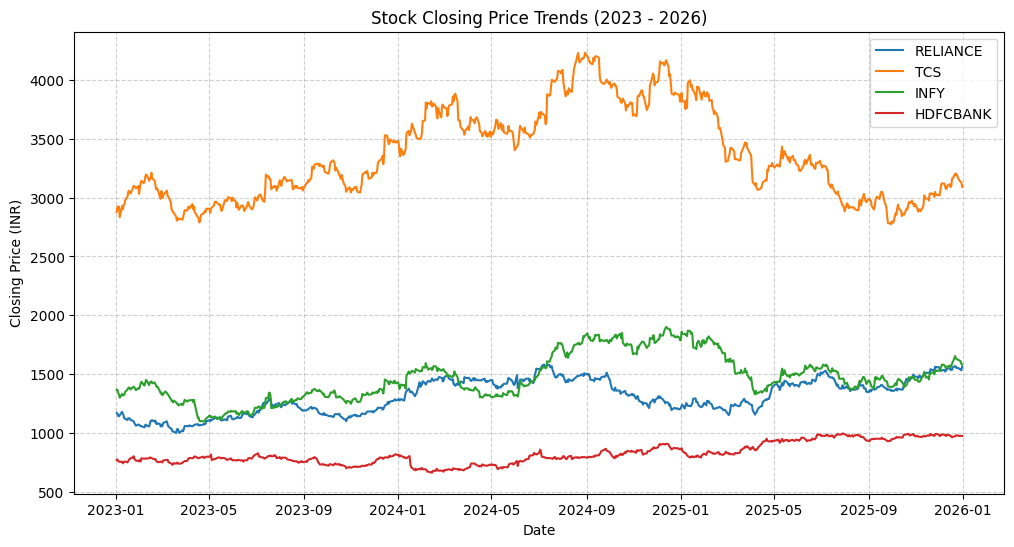

In [33]:
# 6. EDA Visualization (Price Trends)
plt.figure(figsize=(12, 6))
for ticker in tickers[:4]: # Pehle 4 stocks ka trend plot karte hain
    subset = df_final[df_final['Ticker'] == ticker.replace('.NS', '')]
    plt.plot(subset['Date'], subset['Close'], label=ticker.replace('.NS', ''))

plt.title('Stock Closing Price Trends (2023 - 2026)')
plt.xlabel('Date')
plt.ylabel('Closing Price (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [34]:
# 7. Final Cleaned Dataset Export for SQL
output_filename = 'Cleaned_Stock_Historical_Data.csv'
df_final.to_csv(output_filename, index=False)
print(f"\nData successfully cleaned, analyzed, and saved as '{output_filename}' ready for SQL!")


Data successfully cleaned, analyzed, and saved as 'Cleaned_Stock_Historical_Data.csv' ready for SQL!


In [37]:
import sqlite3
import pandas as pd

# Connection banayein
conn = sqlite3.connect('financial_portfolio.db')

print("--- 1. Market Liquidity (Average Trading Volume by Stock) ---")
query_volume = """
SELECT
    Ticker,
    ROUND(AVG(Volume), 2) AS Avg_Daily_Volume
FROM stock_historical_prices
GROUP BY Ticker
ORDER BY Avg_Daily_Volume DESC;
"""
df_volume = pd.read_sql(query_volume, conn)
display(df_volume)


print("\n--- 2. Moving Average Trend Analysis (Latest Date Data) ---")
query_ma = """
SELECT
    Date,
    Ticker,
    ROUND(Close, 2) AS Close_Price,
    ROUND(SMA_50, 2) AS SMA_50,
    ROUND(SMA_200, 2) AS SMA_200
FROM stock_historical_prices
WHERE Date = (SELECT MAX(Date) FROM stock_historical_prices);
"""
df_ma = pd.read_sql(query_ma, conn)
display(df_ma)


print("\n--- 3. Stock Volatility / Daily Return Summary ---")
query_returns = """
SELECT
    Ticker,
    ROUND(MAX(Daily_Return_Pct), 2) AS Max_Single_Day_Gain_Pct,
    ROUND(MIN(Daily_Return_Pct), 2) AS Max_Single_Day_Drop_Pct
FROM stock_historical_prices
GROUP BY Ticker;
"""
df_returns = pd.read_sql(query_returns, conn)
display(df_returns)

# Connection close karein
conn.close()

--- 1. Market Liquidity (Average Trading Volume by Stock) ---


,Ticker,Avg_Daily_Volume
0,HDFCBANK,31386178.22
1,SBIN,14876959.61
2,ITC,14275386.71
3,ICICIBANK,14053400.27
4,RELIANCE,12615818.03
5,INFY,7089138.79
6,TCS,2344959.23
7,LT,2123348.10



--- 2. Moving Average Trend Analysis (Latest Date Data) ---


,Date,Ticker,Close_Price,SMA_50,SMA_200
0,2025-12-31,RELIANCE,1563.17,1518.51,1412.39
1,2025-12-31,TCS,3089.89,3032.34,3107.59
2,2025-12-31,INFY,1581.18,1523.81,1481.77
3,2025-12-31,HDFCBANK,975.07,979.26,951.16
4,2025-12-31,ITC,384.26,387.62,392.08
5,2025-12-31,ICICIBANK,1331.67,1355.11,1380.40
6,2025-12-31,LT,4044.00,3965.27,3612.93
7,2025-12-31,SBIN,964.81,942.07,827.59



--- 3. Stock Volatility / Daily Return Summary ---


,Ticker,Max_Single_Day_Gain_Pct,Max_Single_Day_Drop_Pct
0,HDFCBANK,4.63,-8.44
1,ICICIBANK,4.72,-7.63
2,INFY,7.93,-9.42
3,ITC,5.50,-4.55
4,LT,6.28,-12.67
5,RELIANCE,7.02,-7.49
6,SBIN,9.07,-14.40
7,TCS,6.63,-4.22
